In [102]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from jax import grad, vmap, random
from triangular_transport.flows.dataloaders import log_normal_reference_sampler
from lv import LV
from ot.sliced import sliced_wasserstein_distance as swd

plt.style.use("ggplot")

In [46]:
gen_seed = 3
gen_key = random.key(gen_seed)
us = log_normal_reference_sampler(
    key=gen_key,
    shape=(100000, 4),
    mu=jnp.array([-0.125, -3.0, -0.125, -3.0]), 
    sigma=1 / jnp.sqrt(2),
)
log_us = jnp.log(us)

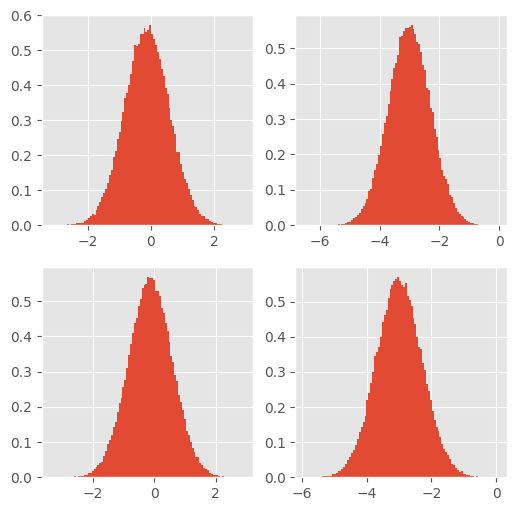

In [48]:
fig, ax = plt.subplots(2, 2, figsize=(6,6))

ax[0, 0].hist(log_us[:, 0], bins=100, density=True);
ax[0, 1].hist(log_us[:, 1], bins=100, density=True);
ax[1, 0].hist(log_us[:, 2], bins=100, density=True);
ax[1, 1].hist(log_us[:, 3], bins=100, density=True);

In [51]:
no_samples = 1
u_true = jnp.array([0.83194674, 0.04134147, 1.0823151, 0.03991483]) # TODO: Need to figure out how to get u_true here from a y_obs.
sigma = 1.0
mean = np.load("log_y_mean.npy")
std = np.load("log_y_std.npy")
lv_sampler = LV(
    seed=0,
    no_samples=no_samples,
    prior_sampler=log_normal_reference_sampler,
    likelihood_sampler=log_normal_reference_sampler,
    normalize=False,
    u_true=u_true,
    sigma=sigma,
    dt0=0.1,
    log_y_mean=mean,
    log_y_std=std
)
yobs = np.log(np.load("y_moderate.npy"))

def log_posterior(u):
    return lv_sampler.log_posterior(yobs, u)

In [80]:
posterior_probs = vmap(log_posterior)(log_us)
mask = ~jnp.isnan(posterior_probs)
post_probs = posterior_probs[mask]
post_probs = post_probs[post_probs <= 0]

In [81]:
post_probs.shape

(99145,)

In [82]:
jnp.argmax(post_probs)

Array(85303, dtype=int32)

In [83]:
jnp.where(posterior_probs == post_probs[85303])

(Array([86051], dtype=int32),)

In [84]:
log_posterior(log_us[86051])

Array(-0.41836405, dtype=float32)

In [99]:
post_max = lv_sampler.log_posterior(yobs, log_us[86051])
post_vals = vmap(lv_sampler.posterior, in_axes=(None, 0))(yobs, log_us)

In [100]:
post_max

Array(-0.41836405, dtype=float32)

In [198]:
jnp.where(post_vals >= 0.34)

(Array([ 2536, 23216, 33271, 49296, 56350, 56807, 71728, 81666, 86051,
        89878, 97727], dtype=int32),)

In [199]:
vmap(lv_sampler.prior_pdf)(log_us[jnp.where(post_vals >= 0.34)])

Array([0.03682638, 0.01504909, 0.01190231, 0.02076116, 0.01115458,
       0.02023131, 0.03046864, 0.03093005, 0.03140988, 0.0221535 ,
       0.00300595], dtype=float32)

In [200]:
us_post = us[jnp.where(post_vals >= 0.34)]
pkey = random.key(3)
us_post_noise = np.log(us_post) + 0.1 * random.normal(pkey, us_post.shape)
us_post_noise = np.exp(us_post_noise)

In [201]:
us_post

Array([[1.2636093 , 0.06325679, 0.55587316, 0.02276663],
       [1.415156  , 0.06948061, 0.54720986, 0.01561514],
       [1.4982585 , 0.08019675, 0.5443714 , 0.01524473],
       [1.3274457 , 0.08285505, 0.5228168 , 0.01943337],
       [1.3676412 , 0.0961014 , 0.500951  , 0.01619399],
       [1.3246096 , 0.04983301, 0.5914962 , 0.016018  ],
       [1.3309516 , 0.05175443, 0.5851161 , 0.01967026],
       [1.282813  , 0.06383872, 0.56587875, 0.02049976],
       [1.2859961 , 0.05131162, 0.5939614 , 0.01957195],
       [1.39012   , 0.05309442, 0.5956782 , 0.01699556],
       [1.6577455 , 0.10490073, 0.49590963, 0.01117367]], dtype=float32)

In [202]:
us_post_noise

array([[1.0934594 , 0.0737839 , 0.5775475 , 0.02772588],
       [1.3343885 , 0.07095098, 0.48313665, 0.01515156],
       [1.3826171 , 0.07158427, 0.5799936 , 0.01377953],
       [1.2599581 , 0.07761878, 0.6300031 , 0.01717048],
       [1.3726043 , 0.09823196, 0.53790134, 0.01491005],
       [1.3792137 , 0.04489931, 0.54886186, 0.01825135],
       [1.2800905 , 0.04857126, 0.5765824 , 0.02093153],
       [1.226141  , 0.06007207, 0.5422419 , 0.02063971],
       [1.530149  , 0.05231736, 0.5388878 , 0.02205209],
       [1.3437873 , 0.05169456, 0.61026484, 0.0175203 ],
       [1.8311814 , 0.10546093, 0.68157405, 0.01234332]], dtype=float32)

In [203]:
# us_true = np.load("true_samps/true_us_rare_obs_3.npy")[::10, :]
# us_true = np.load("true_samps/true_us_obs.npy")[::20, :]
us_true = np.load("true_samps/true_us_moderate_obs_2.npy")[::35, :]
# true_us3 = np.load("true_samps/true_us_moderate_obs_3.npy")[::20, :]
# true_us4 = np.load("true_samps/true_us_moderate_obs_4.npy")[::20, :]

# us_true = np.exp(np.vstack([true_us1, true_us2, true_us3]))
np.random.shuffle(us_true)
us_true = np.exp(us_true)

In [204]:
np.mean(us_true, axis=0)

array([1.06742956, 0.04326198, 1.01759721, 0.18224482])

In [191]:
mod_swd = 0.5823165406083023

In [207]:
swd_seed = 2
n_projections = 512
post_swd = swd(
    np.asarray(us_post_noise)[8:9, :],
    us_true,
    a=np.ones(len(us_post)) / len(us_post),
    b=np.ones(len(us_true)) / len(us_true),
    n_projections=n_projections,
    seed=swd_seed,
    p=2,
)
post_swd / mod_swd

np.float64(0.6071111941226341)

In [ ]:
np.save("init_points_mod.npy", us_post_noise)

: 

In [3]:
import numpy as np
train_data = np.load("training_data.npy")
ys, us = train_data[:, :18], train_data[:, 18:]
us[25]

array([0.6043533 , 0.02088149, 2.5632644 , 0.02922795], dtype=float32)

In [ ]:
[0.55718614 0.02073706 2.67125513 0.03174984]